In [29]:
import pandas as pd
import os

# Укажите путь к вашему файлу
df = pd.read_csv("script_5/transcript_clean_without_no_answer.csv")

# Создаём папку "тест", если её нет
os.makedirs("тест", exist_ok=True)

# Подготовим строку для записи
output_lines = []

output_lines.append("🔍 Значения в колонке 'result' и их количество:\n")
result_counts = df['result'].value_counts(dropna=False).sort_index()
for val, count in result_counts.items():
    output_lines.append(f"{val} : {count}")

output_lines.append("\n" + "="*60 + "\n")

output_lines.append("🔍 Значения в колонке 'status' и их количество:\n")
status_counts = df['status'].value_counts(dropna=False).sort_index()
for val, count in status_counts.items():
    output_lines.append(f"{val} : {count}")

# Записываем в файл
with open("тест/counts_report.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(output_lines))

# Опционально: по-прежнему выводим в консоль
print("\n".join(output_lines))

🔍 Значения в колонке 'result' и их количество:

ЛПР временно недоступен : 2
Не удалось записать номер телефона : 40
абонент постоянно переспрашивает : 2
дефолтные ответы : 20
нет бизнеса : 83
нет возможности соединить с ЛПР : 69
неудобно говорить после приветствия : 7
ничего не надо - до озвучивания оффера : 9
отказ - возражение без конкретики : 144
отказ - вопрос в какую компанию звоните : 38
отказ - вопрос какие номера : 18
отказ - вопрос какие услуги : 1
отказ - вопрос не по теме звонка : 53
отказ - вопрос о компании : 44
отказ - вопрос о личном кабинете : 3
отказ - вопрос о смене названия : 2
отказ - вопрос почему сами не проконсультируете : 9
отказ - вопрос про юр.лицо : 10
отказ - дорого : 19
отказ - другая симка : 59
отказ - личный вопрос : 3
отказ - не знает : 190
отказ - не корпоративный номер : 35
отказ - не пользуется : 118
отказ - не понял : 78
отказ - не устраивает качество обслуживания : 8
отказ - не устраивает качество услуг : 45
отказ - не устраивает тариф : 1
отказ - н

In [31]:

print("\n📊 Топ-20 значений 'status' по частоте:")
print(df['status'].value_counts())


📊 Топ-20 значений 'status' по частоте:
status
угроза оттока не подтверждена                                               2158
угроза оттока не определена                                                 1759
угроза оттока подтверждена                                                  1033
недозвон                                                                     562
угроза оттока не определена, требуется уточнение персонального менеджера     231
негатив клиента от звонка                                                    127
обновить контактные данные                                                    18
угроза оттока не подтверждена, работает только на входящих / смс               6
угроза оттока не подтверждена, только для работы оборудования                  6
Name: count, dtype: int64


In [30]:
import pandas as pd

# Загрузите ваш файл (убедитесь, что он находится в среде Colab)
df = pd.read_csv("script_1/transcript_without_no_reply.csv")

# Посчитать все значения в 'status', включая NaN
status_counts = df['status'].value_counts(dropna=False)

# Вывести таблицу в виде красивого DataFrame (отображается в Colab как таблица)
print("🔍 Все значения в колонке 'status' и их количество:\n")
display(status_counts.to_frame(name='Количество'))

🔍 Все значения в колонке 'status' и их количество:



,Количество
status,
угроза оттока не подтверждена,2158
угроза оттока не определена,1759
угроза оттока подтверждена,1033
недозвон,562
"угроза оттока не определена, требуется уточнение персонального менеджера",231
негатив клиента от звонка,127
обновить контактные данные,18
"угроза оттока не подтверждена, работает только на входящих / смс",6
"угроза оттока не подтверждена, только для работы оборудования",6


In [32]:
import pandas as pd

df = pd.read_csv("script_1/transcript_without_no_reply.csv")

print("🔍 Все значения в колонке 'status' и их количество:\n")
for val, count in df['status'].value_counts(dropna=False).sort_index().items():
    print(f"{val} : {count}")

🔍 Все значения в колонке 'status' и их количество:

негатив клиента от звонка : 127
недозвон : 562
обновить контактные данные : 18
угроза оттока не определена : 1759
угроза оттока не определена, требуется уточнение персонального менеджера : 231
угроза оттока не подтверждена : 2158
угроза оттока не подтверждена, работает только на входящих / смс : 6
угроза оттока не подтверждена, только для работы оборудования : 6
угроза оттока подтверждена : 1033


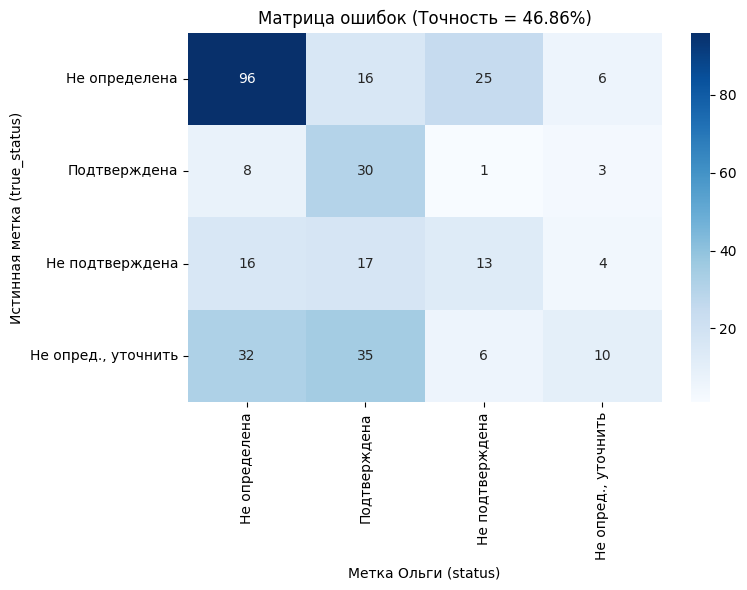

Общая точность: 46.86%


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

# Загружаем данные
df = pd.read_csv('320.csv')

# Предполагается, что status — метка Ольги, true_status — истинная
y_pred = df['status']
y_true = df['true_status']

# Строим матрицу ошибок
cm = confusion_matrix(y_true, y_pred, labels=[1, 2, 3, 4])

# Вычисляем точность
acc = accuracy_score(y_true, y_pred)

# Визуализация
labels_text = ['Не определена', 'Подтверждена', 'Не подтверждена', 'Не опред., уточнить']
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_text,
    yticklabels=labels_text,
    cbar=True
)
plt.title(f'Матрица ошибок (Точность = {acc:.2%})')
plt.xlabel('Метка Ольги (status)')
plt.ylabel('Истинная метка (true_status)')
plt.tight_layout()
plt.show()

# Дополнительно: распечатать точность
print(f"Общая точность: {acc:.2%}")

✅ МАТРИЦА ОШИБОК (БИНАРНАЯ):
                      Ольга: Остающиеся   Ольга: Уходящие
Истина: Остающиеся               13                 37
Истина: Уходящие                  32                236

📈 Точность (Accuracy):      78.30%
🎯 Полнота (Recall):         88.06%
🔍 Точность (Precision):     86.45%
📊 F1-мера:                  87.25%

❗ Пропущено уходящих:       32
   Доля от всех уходящих:   11.94%


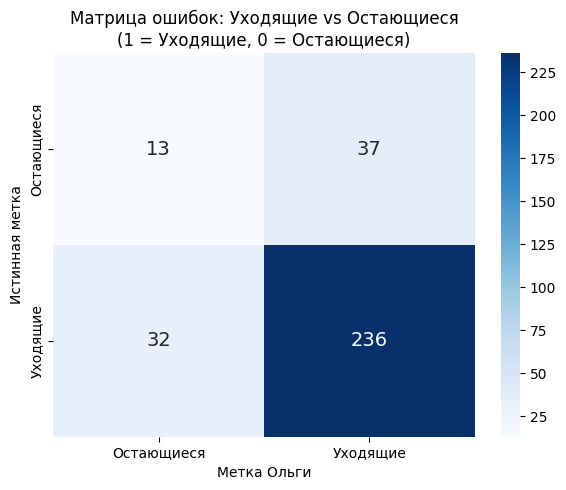

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

# Загрузка данных
df = pd.read_csv('320.csv')

# Перекодировка в бинарные классы
def to_binary(label):
    if label == 3:  # Не подтверждена → остающийся
        return 0
    else:           # 1, 2, 4 → уходящие
        return 1

y_true = df['true_status'].apply(to_binary)
y_pred = df['status'].apply(to_binary)

# Матрица ошибок
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

# Метрики
accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred, pos_label=1)  # для класса "Уходящие"
precision = precision_score(y_true, y_pred, pos_label=1)
f1 = f1_score(y_true, y_pred, pos_label=1)
false_negatives = cm[1, 0]  # пропущенные уходящие

# Вывод в консоль
print("✅ МАТРИЦА ОШИБОК (БИНАРНАЯ):")
print("                      Ольга: Остающиеся   Ольга: Уходящие")
print(f"Истина: Остающиеся       {cm[0,0]:>10}         {cm[0,1]:>10}")
print(f"Истина: Уходящие          {cm[1,0]:>10}         {cm[1,1]:>10}")
print()
print(f"📈 Точность (Accuracy):      {accuracy:.2%}")
print(f"🎯 Полнота (Recall):         {recall:.2%}")
print(f"🔍 Точность (Precision):     {precision:.2%}")
print(f"📊 F1-мера:                  {f1:.2%}")
print()
print(f"❗ Пропущено уходящих:       {false_negatives}")
print(f"   Доля от всех уходящих:   {false_negatives / (cm[1,0] + cm[1,1]):.2%}")

# Визуализация
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Остающиеся', 'Уходящие'],
    yticklabels=['Остающиеся', 'Уходящие'],
    annot_kws={"size": 14}
)
plt.title('Матрица ошибок: Уходящие vs Остающиеся\n(1 = Уходящие, 0 = Остающиеся)', fontsize=12)
plt.xlabel('Метка Ольги')
plt.ylabel('Истинная метка')
plt.tight_layout()
plt.show()